In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import torch 


for gpu_id in range(torch.cuda.device_count()):
    print(gpu_id, torch.cuda.get_device_name(gpu_id))

0 NVIDIA RTX A5000
1 NVIDIA RTX A5000
2 NVIDIA RTX A5000
3 NVIDIA RTX A5000
4 NVIDIA RTX A5000
5 NVIDIA RTX A5000
6 NVIDIA RTX A5000
7 NVIDIA RTX A5000


In [3]:
from pathlib import Path
import cv2
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.config import DATASET_ROOT

VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv"}

## Analysis shows:

1. 2000 total videos
2. 1600 videos for training & 400 videos for validation
3. all vidoes have the .avi extension
4. 0 duplicate videos
5. 0 corrupted videos
6. all videos have: 5 second duration, 30 fps, 150 total frames per video
7. videos vary in resolution size (77 total height-width combinations)

In [4]:
def find_videos(root):
    videos = []

    for split in ['train','val']:
        for label in ['Fight', 'NonFight']:
            folder = root / split / label

            for video_path in folder.iterdir():
                if video_path.suffix.lower() in VIDEO_EXTENSIONS:
                    videos.append({
                        'path': video_path,
                        'filename': video_path.name,
                        'split': split,
                        'label': label,
                        'extension': video_path.suffix.lower()
                    })
    
    return pd.DataFrame(videos)

df = find_videos(DATASET_ROOT)

print(len(df))

2000


In [5]:
# check for the expected training/validation split and class balance
pd.crosstab(df["split"], df["label"])

label,Fight,NonFight
split,,
train,800,800
val,200,200


In [6]:
# check extensions
df.extension.value_counts()

extension
.avi    2000
Name: count, dtype: int64

In [7]:
# check for duplicated files
duplicate_files = df[df.duplicated(subset=["path"], keep=False)]

print("Duplicate filenames:", len(duplicate_files))
duplicate_files.head()

Duplicate filenames: 0


,path,filename,split,label,extension


In [8]:
def get_video_metadata(video_path):
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        return {
            "readable": False,
            "fps": None,
            "frame_count": None,
            "duration_sec": None,
            "width": None,
            "height": None
        }
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    
    duration_sec = None
    if fps and fps > 0:
        duration_sec = frame_count / fps
    
    cap.release()
    
    return {
        "readable": True,
        "fps": fps,
        "frame_count": frame_count,
        "duration_sec": duration_sec,
        "width": int(width),
        "height": int(height)
    }

In [9]:
metadata = []

for path in tqdm(df["path"], desc="Auditing videos"):
    metadata.append(get_video_metadata(path))

metadata_df = pd.DataFrame(metadata)
audit_df = pd.concat([df, metadata_df], axis=1)

audit_df.head()

Auditing videos: 100%|██████████| 2000/2000 [00:00<00:00, 5301.27it/s]


,path,filename,split,label,extension,readable,fps,frame_count,duration_sec,width,height
0,/homes/mp2940/demo/datasets/rwf-2000/RWF-2000/...,-1l5631l3fg_0.avi,train,Fight,.avi,True,30.0,150.0,5.0,640,360
1,/homes/mp2940/demo/datasets/rwf-2000/RWF-2000/...,-1l5631l3fg_1.avi,train,Fight,.avi,True,30.0,150.0,5.0,640,360
2,/homes/mp2940/demo/datasets/rwf-2000/RWF-2000/...,-1l5631l3fg_2.avi,train,Fight,.avi,True,30.0,150.0,5.0,640,360
3,/homes/mp2940/demo/datasets/rwf-2000/RWF-2000/...,0H2s9UJcNJ0_0.avi,train,Fight,.avi,True,30.0,150.0,5.0,1280,720
4,/homes/mp2940/demo/datasets/rwf-2000/RWF-2000/...,0H2s9UJcNJ0_2.avi,train,Fight,.avi,True,30.0,150.0,5.0,1280,720


In [14]:
corrupted = audit_df[audit_df["readable"] == False]

print("Unreadable/corrupted videos:", len(corrupted))
display(corrupted)

Unreadable/corrupted videos: 0


,path,filename,split,label,extension,readable,fps,frame_count,duration_sec,width,height,resolution


In [15]:
summary = audit_df.groupby(["split", "label"]).agg(
    num_videos=("path", "count"),
    avg_duration_sec=("duration_sec", "mean"),
    min_duration_sec=("duration_sec", "min"),
    max_duration_sec=("duration_sec", "max"),

    avg_fps=("fps", "mean"),
    min_fps=("fps", "min"),
    max_fps=("fps", "max"),


    avg_frame_count=("frame_count", "mean"),
    min_frame_count=("frame_count", "min"),
    max_frame_count=("frame_count", "max"),

    avg_width=("width", "mean"),
    min_width=("width", "min"),
    max_width=("width", "max"),

    avg_height=("height", "mean"),
    min_height=("height", "min"),
    max_height=("height", "max"),

).reset_index()

display(summary)

,split,label,num_videos,avg_duration_sec,min_duration_sec,max_duration_sec,avg_fps,min_fps,max_fps,avg_frame_count,min_frame_count,max_frame_count,avg_width,min_width,max_width,avg_height,min_height,max_height
0,train,Fight,800,5.0,5.0,5.0,30.0,30.0,30.0,150.0,150.0,150.0,823.4250,204,1920,491.9075,188,1080
1,train,NonFight,800,5.0,5.0,5.0,30.0,30.0,30.0,150.0,150.0,150.0,612.0775,320,1920,387.7200,216,1080
2,val,Fight,200,5.0,5.0,5.0,30.0,30.0,30.0,150.0,150.0,150.0,911.8000,300,1920,553.5900,240,1080
3,val,NonFight,200,5.0,5.0,5.0,30.0,30.0,30.0,150.0,150.0,150.0,588.6400,320,1280,381.2000,240,720


In [12]:
audit_df["resolution"] = audit_df["width"].astype(str) + "x" + audit_df["height"].astype(str)

display(audit_df["resolution"].value_counts())

resolution
320x240      700
1280x720     628
640x360      169
480x360       89
1920x1080     31
            ... 
566x360        1
948x720        1
620x312        1
320x246        1
432x240        1
Name: count, Length: 77, dtype: int64

AttributeError: 'Series' object has no attribute 'iteritems'

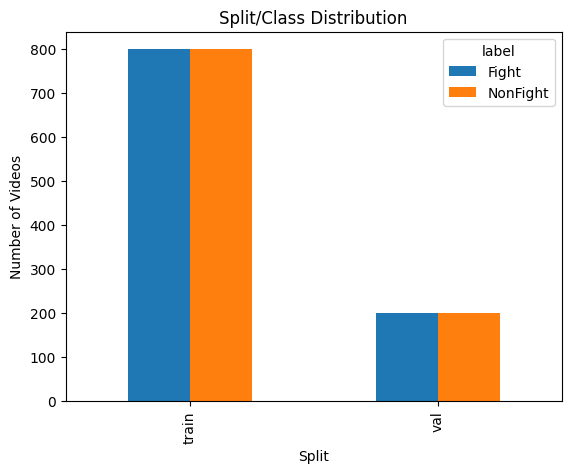

In [13]:
pd.crosstab(audit_df["split"], audit_df["label"]).plot(kind="bar", title="Split/Class Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Videos")
plt.show()